### Time to get your hands dirty.  The transient Universe


Let's go back to our previous example on the astrophysical transient.


8) Fit the same burst from before with the same priors,  but this time use nested sampling.

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

Be careful with how you transform your parameter space into a unit hypercube for the nested sampling priors (I used `ppf` from `scipy.stats.uniform`, but there are other ways to do it)

An appropriate check on whether you have done things correctly is that the posterior samples you get from the burst analysis here should give an equivalent corner plot to the MCMC you did earlier.

7) Another possible burst that may explain the data is a Gaussian profile described by:

$y = b + A\exp[-(t-t_0)^2 / 2\sigma_W^2]$

Fit this burst usign nested sampling and reasonable priors (this time is up to you to decide...)

9) Unlike MCMCs, nested sampling provides the Bayesian evidence. Compute the Bayesian evidence for this Gaussian burst, and for the original burst burst. Which burst is the favored description of the data? Express this in terms of the Jeffrey's scale.

In [171]:
import numpy as np
from scipy import stats
from scipy import optimize
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import dynesty

In [172]:
#reading data
data = np.load("/Users/albertodufour/code/astrostatistics_bicocca_2025/solutions/transient.npy")

time ,flux, err = data.T

In [173]:
#defining models
def burst(t, par):
    t = np.asarray(t)
    t0, alpha, A, b = par
    return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))

def gprofile(t, par):
    t = np.asarray(t)
    t0, sigmaW, A, b = par
    return np.where(t<t0,b,b+A*np.exp(-0.5*((t-t0)/sigmaW)**2))



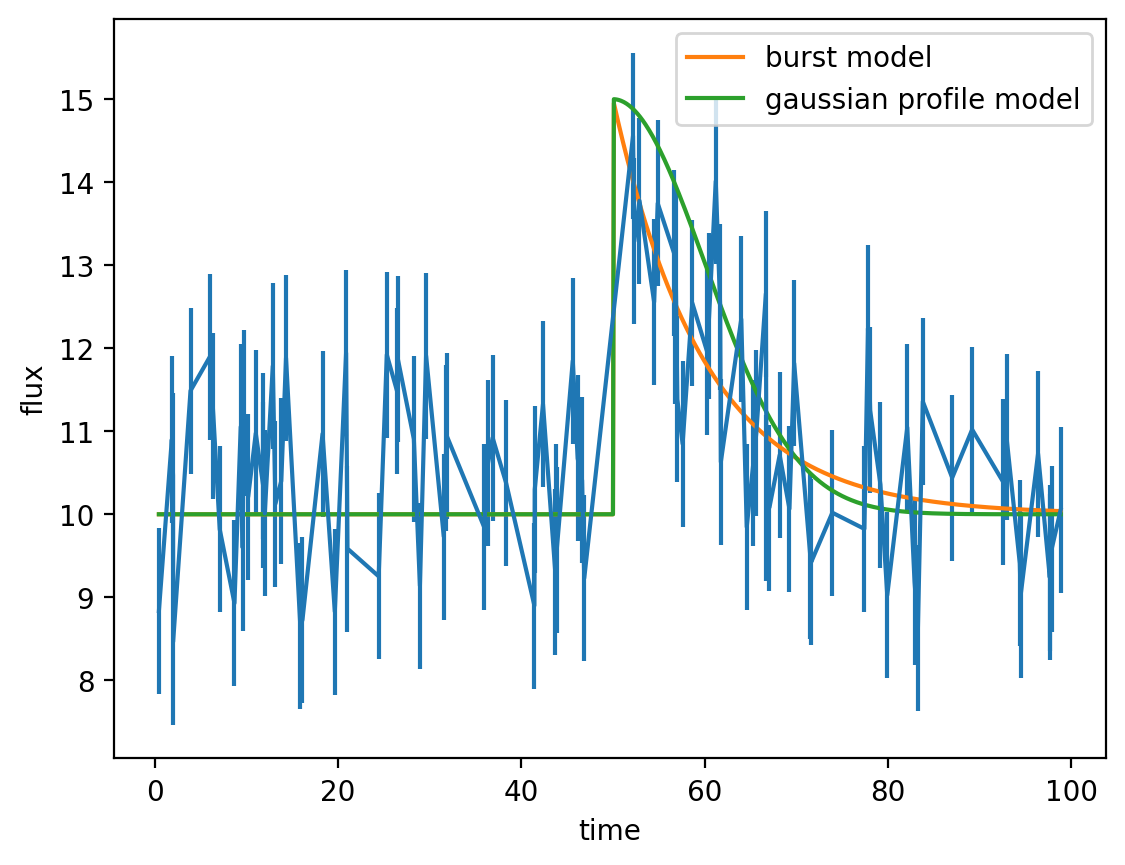

guess for the burst model: [50, 0.1, 5, 10]
guess for the gauss profile model: [50, 0.1, 5, 10]


In [174]:
# guessing params and prliminary plotting

#burst model
guess_burst = [50, 1/10, 5, 10]
bounds_burst = ([20, np.exp(-5), 0, 5], [80, np.exp(5), 10, 20])

#gaussian profile model
guess_gp = [50, 10, 5, 10]
bounds_gp = ([20, np.exp(-5), 0, 5], [80, np.exp(5), 10, 20])

plt.errorbar(time, flux, yerr=err)

xgrid = np.linspace(np.min(time), np.max(time), 1000)
plt.plot(xgrid, burst(xgrid, guess_burst), label="burst model")
plt.plot(xgrid, gprofile(xgrid, guess_gp), label="gaussian profile model")

plt.xlabel("time")
plt.ylabel("flux")
plt.legend()
plt.show()

print(f"guess for the burst model: {guess_burst}")
print(f"guess for the gauss profile model: {guess_burst}")



In [175]:
#----------------------- Likelihood and Priors --------------
def logLikelihood(theta, data, model):
    x, y, sigma_y = data.T
    if model =='burst':
        y_fit = burst(x, theta)
    if model == 'gprofile':
        y_fit = gprofile(x, theta)

    return -0.5 * np.sum((y-y_fit)**2 / sigma_y**2 ) - 0.5 * np.log(np.sqrt(2*np.pi)) - np.log(np.sum(sigma_y))



def ptform(u,model):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest."""

    x = np.array(u)

    # flat prior for t0, b, A
    # flat logprior for alpha/sigma_W (scale invariance)
    if model =='burst':
        for i in [0,2,3]:
            x[i] = stats.uniform(loc=bounds_burst[0][i],scale=bounds_burst[1][i]-bounds_burst[0][1]).ppf(u[i])
        x[1] = stats.loguniform.ppf(u[3],bounds_burst[0][1],bounds_burst[1][1])
    else:
        for i in [0,2,3]:
            x[i] = stats.uniform(loc=bounds_gp[0][i],scale=bounds_gp[1][i]-bounds_gp[0][1]).ppf(u[i])
        x[1] = stats.loguniform.ppf(u[3],bounds_gp[0][1],bounds_gp[1][1])
        #x[3] = scipy.stats.uniform(loc=sigmaWmin,scale=sigmaWmax-sigmaWmin).ppf(u[3])
    # print(x)
    return x
    


In [176]:
#------------ BURST MODEL --------------
# "Static" nested sampling.
ndim=4
sampler = dynesty.NestedSampler(logLikelihood, ptform, ndim, logl_args=[data, "burst"],ptform_args=['burst'])
sampler.run_nested()
burst_results = sampler.results

/var/folders/p0/lxv02_717plcjl85mgd2gz940000gn/T/ipykernel_74931/1341045677.py:5: RuntimeWarning: overflow encountered in exp
  return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))
/var/folders/p0/lxv02_717plcjl85mgd2gz940000gn/T/ipykernel_74931/1341045677.py:5: RuntimeWarning: overflow encountered in multiply
  return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))
2294it [00:40, 34.58it/s, bound: 7 | nc: 5 | ncall: 21942 | eff(%): 10.455 | loglstar:   -inf < -95.333 <    inf | logz: -102.387 +/-  0.109 | dlogz: 43.344 >  0.509]    /var/folders/p0/lxv02_717plcjl85mgd2gz940000gn/T/ipykernel_74931/1341045677.py:5: RuntimeWarning: overflow encountered in exp
  return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))
/var/folders/p0/lxv02_717plcjl85mgd2gz940000gn/T/ipykernel_74931/1341045677.py:5: RuntimeWarning: overflow encountered in multiply
  return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))
2310it [00:42,  7.66it/s, bound: 10 | nc: 237 | ncall: 23100 | eff(%): 10.000 | loglstar:   -inf < -95.053 <

In [182]:
#------------ GAUSSIAN PROFILE MODEL --------------
# "Static" nested sampling.
ndim=4
sampler = dynesty.NestedSampler(logLikelihood, ptform, ndim, logl_args=[data, "gprofile"],ptform_args=['gprofile'])
sampler.run_nested()
gp_results = sampler.results

4929it [05:16,  1.13it/s, bound: 239 | nc: 1223 | ncall: 166314 | eff(%):  2.964 | loglstar:   -inf < -87.505 <    inf | logz: -96.252 +/-  0.101 | dlogz:  4.334 >  0.509]/opt/anaconda3/envs/astro/lib/python3.12/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
5023it [06:31, 15.09it/s, bound: 253 | nc: 7 | ncall: 209751 | eff(%):  2.395 | loglstar:   -inf < -87.133 <    inf | logz: -96.183 +/-  0.103 | dlogz:  4.086 >  0.509]    /opt/anaconda3/envs/astro/lib/python3.12/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is ver

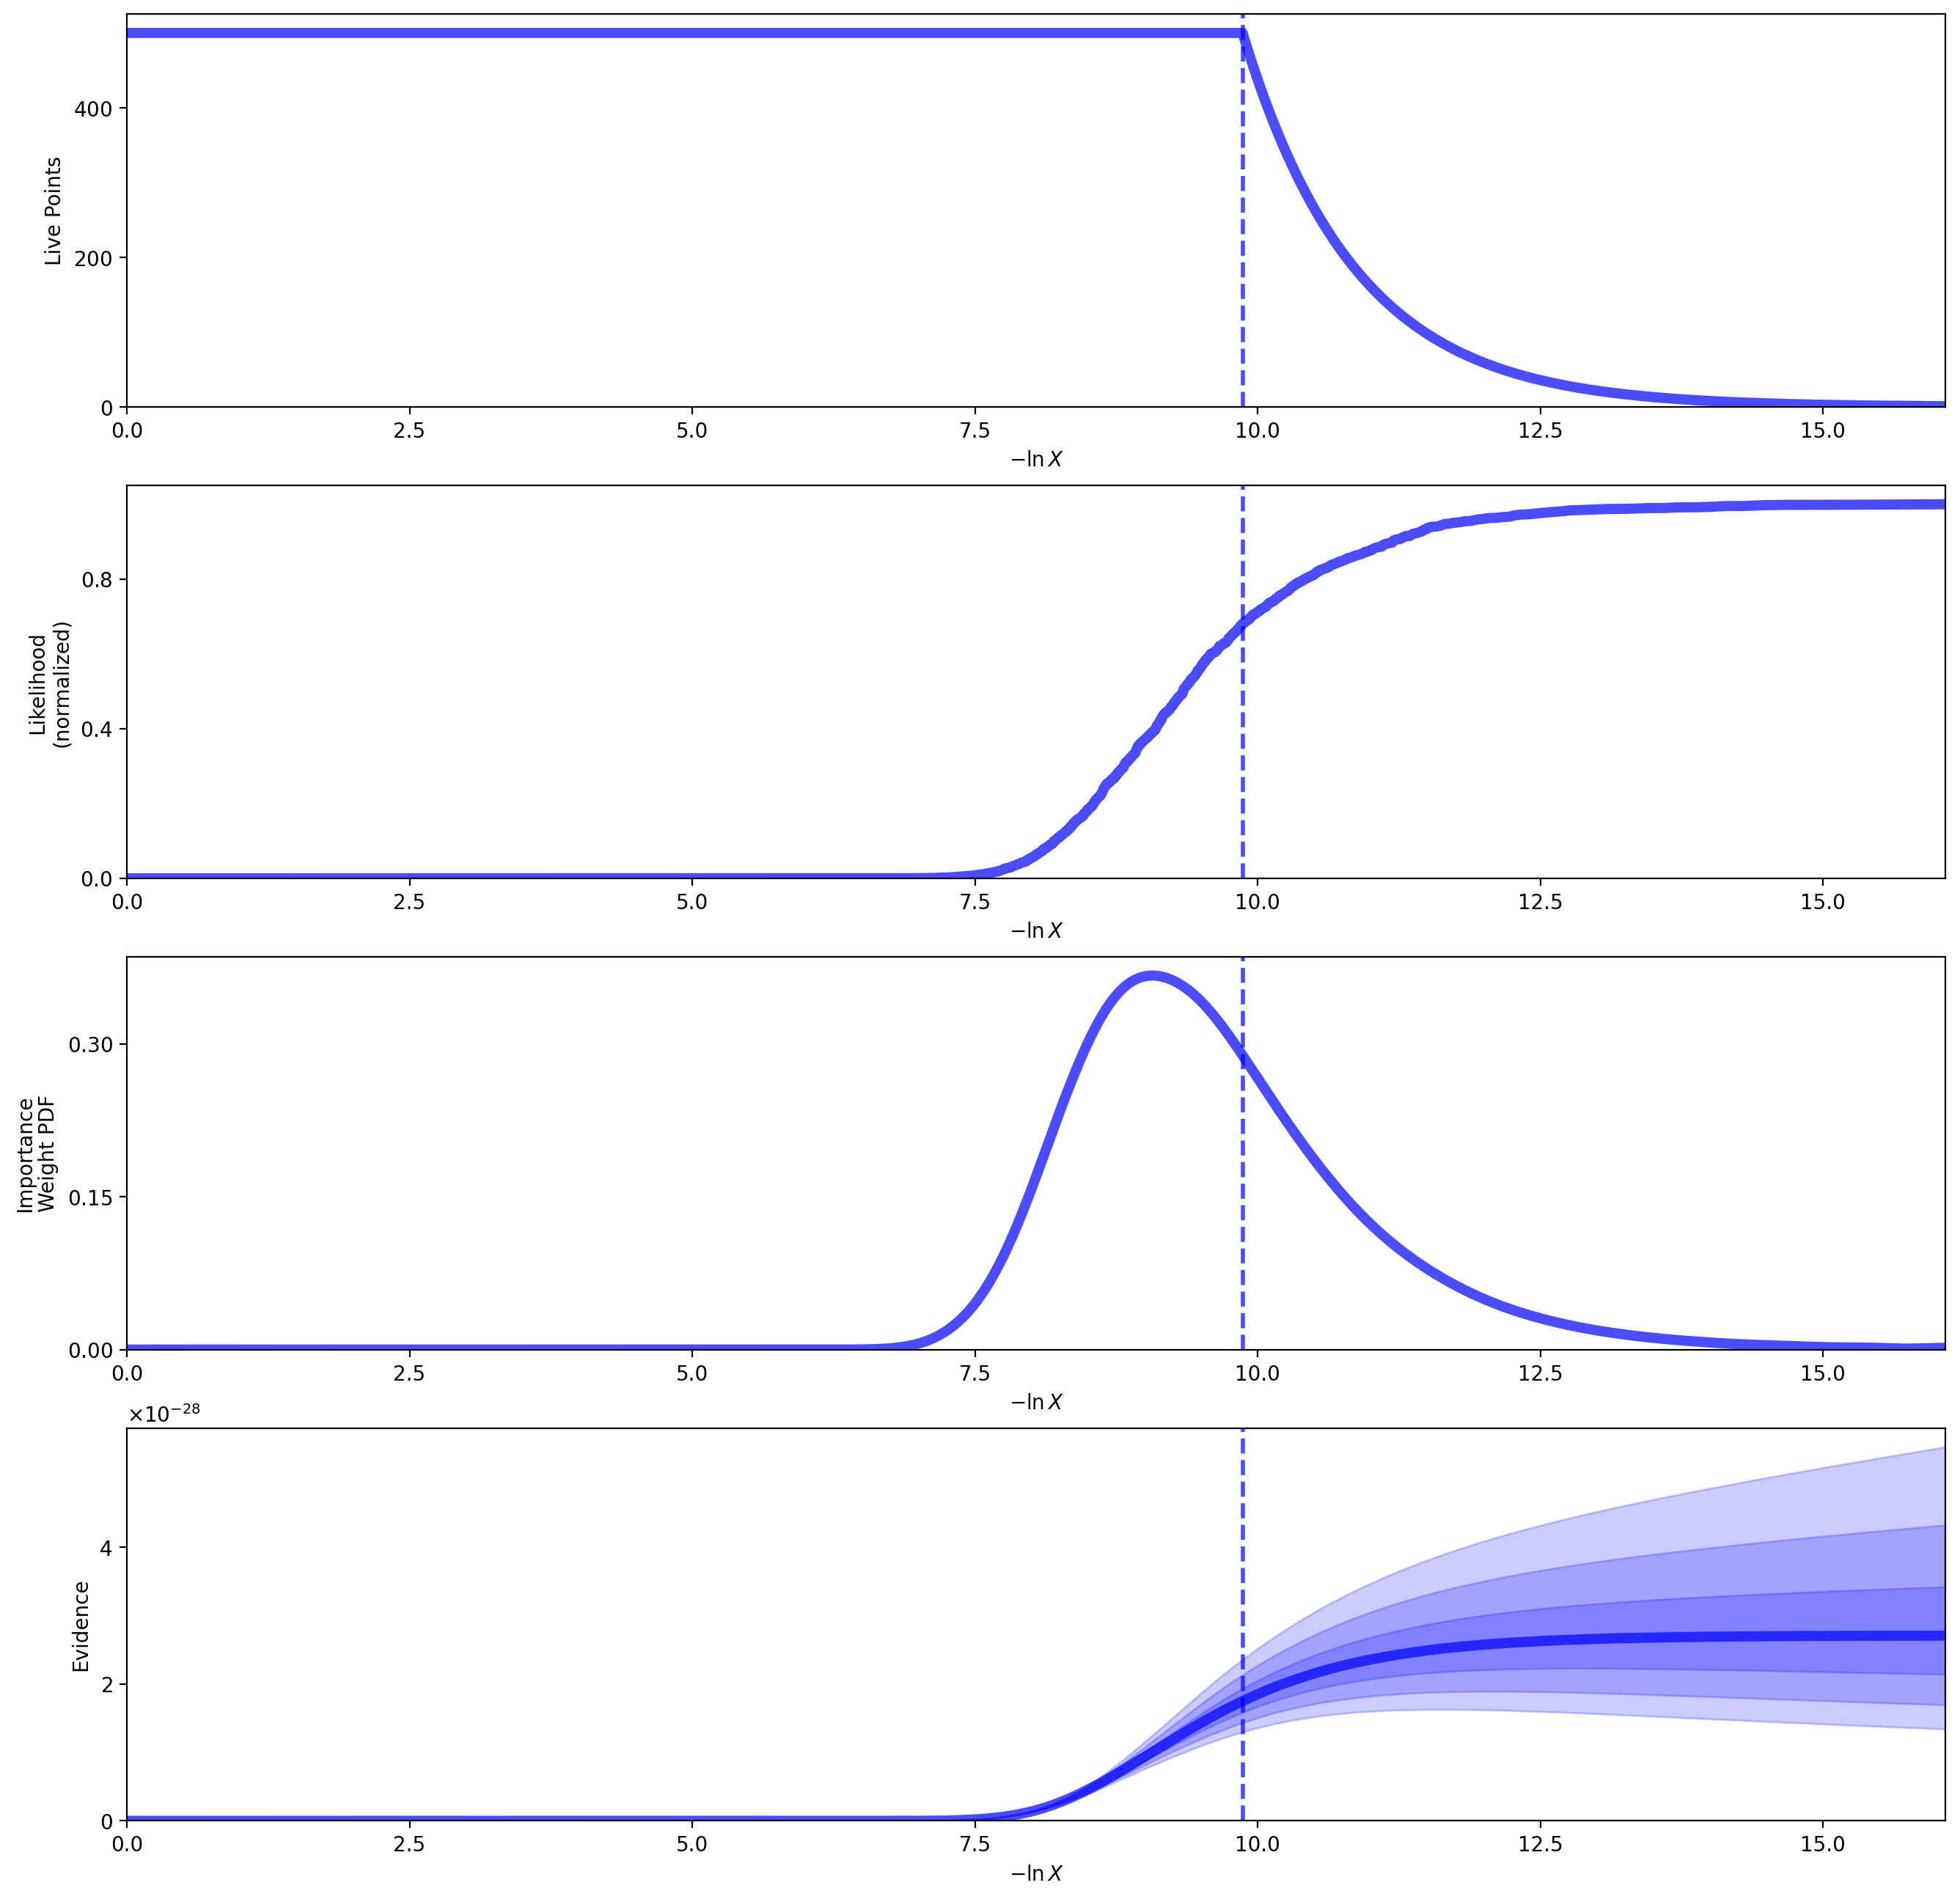

In [178]:
from dynesty import plotting as dyplot

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(gp_results)

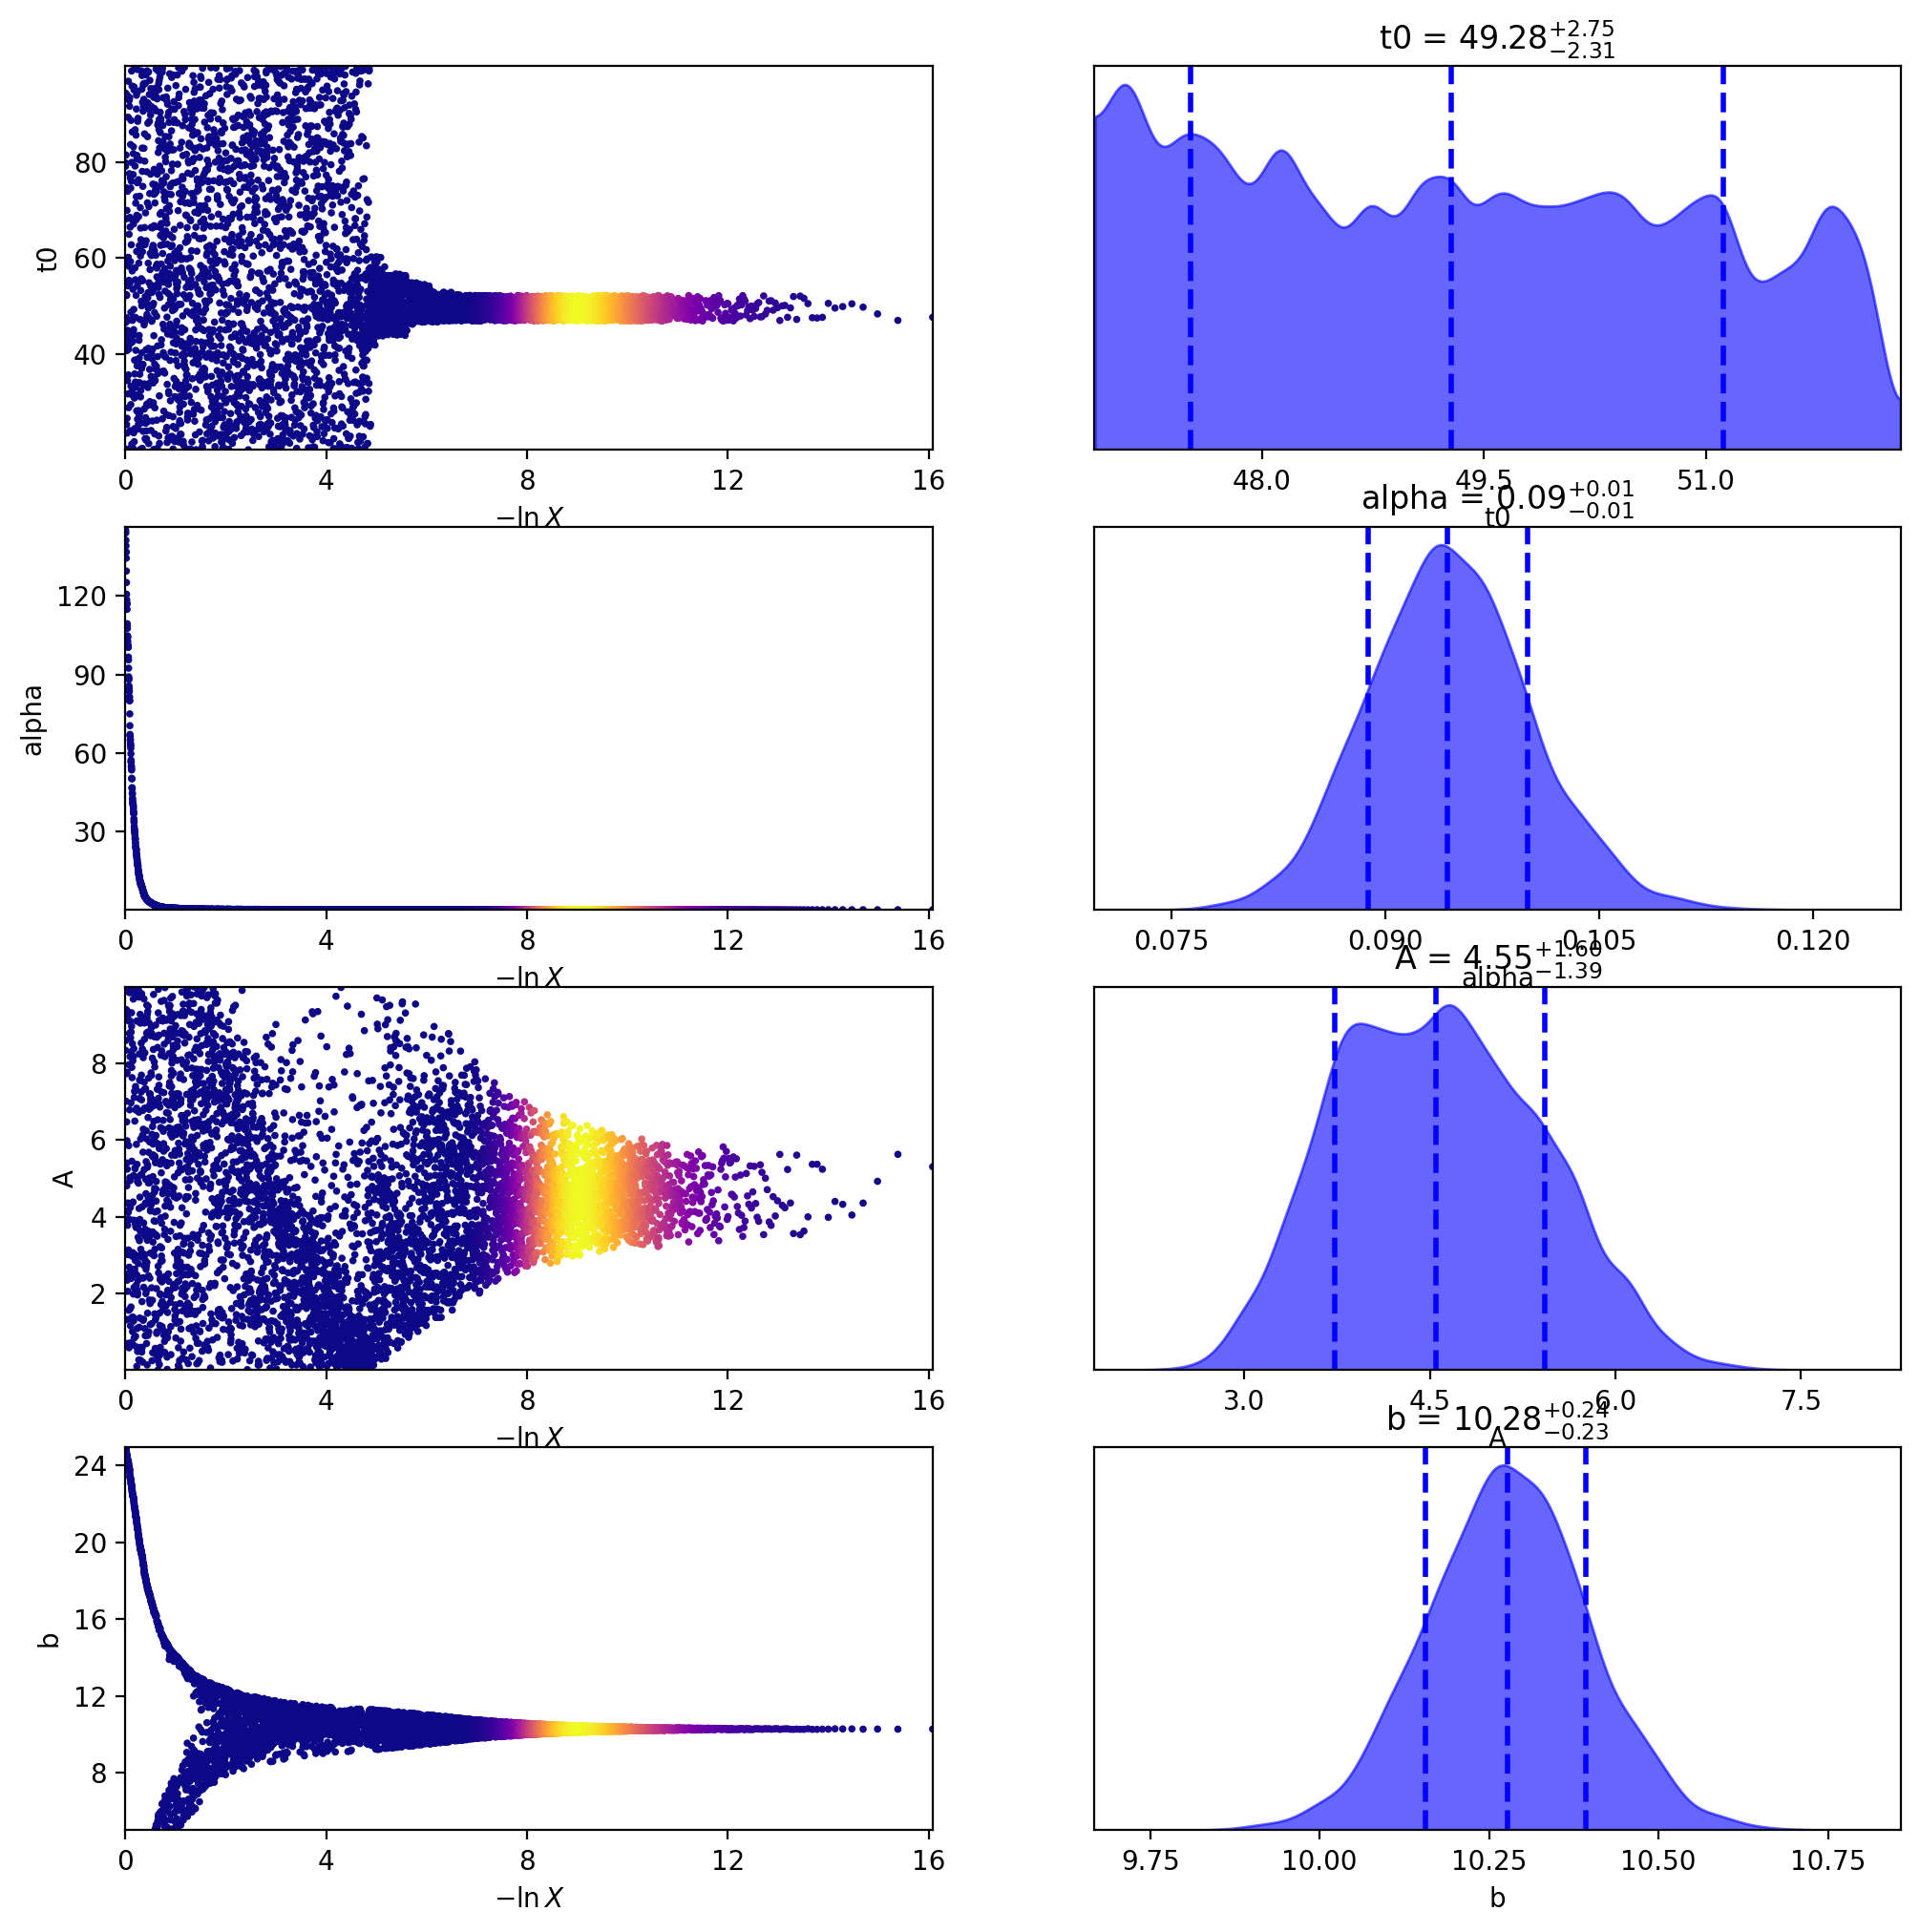

In [179]:
labels = ["t0", "alpha", "A", "b"]
tfig, taxes = dyplot.traceplot(gp_results, labels=labels, show_titles=True, quantiles=[0.16, 0.5, 0.84])

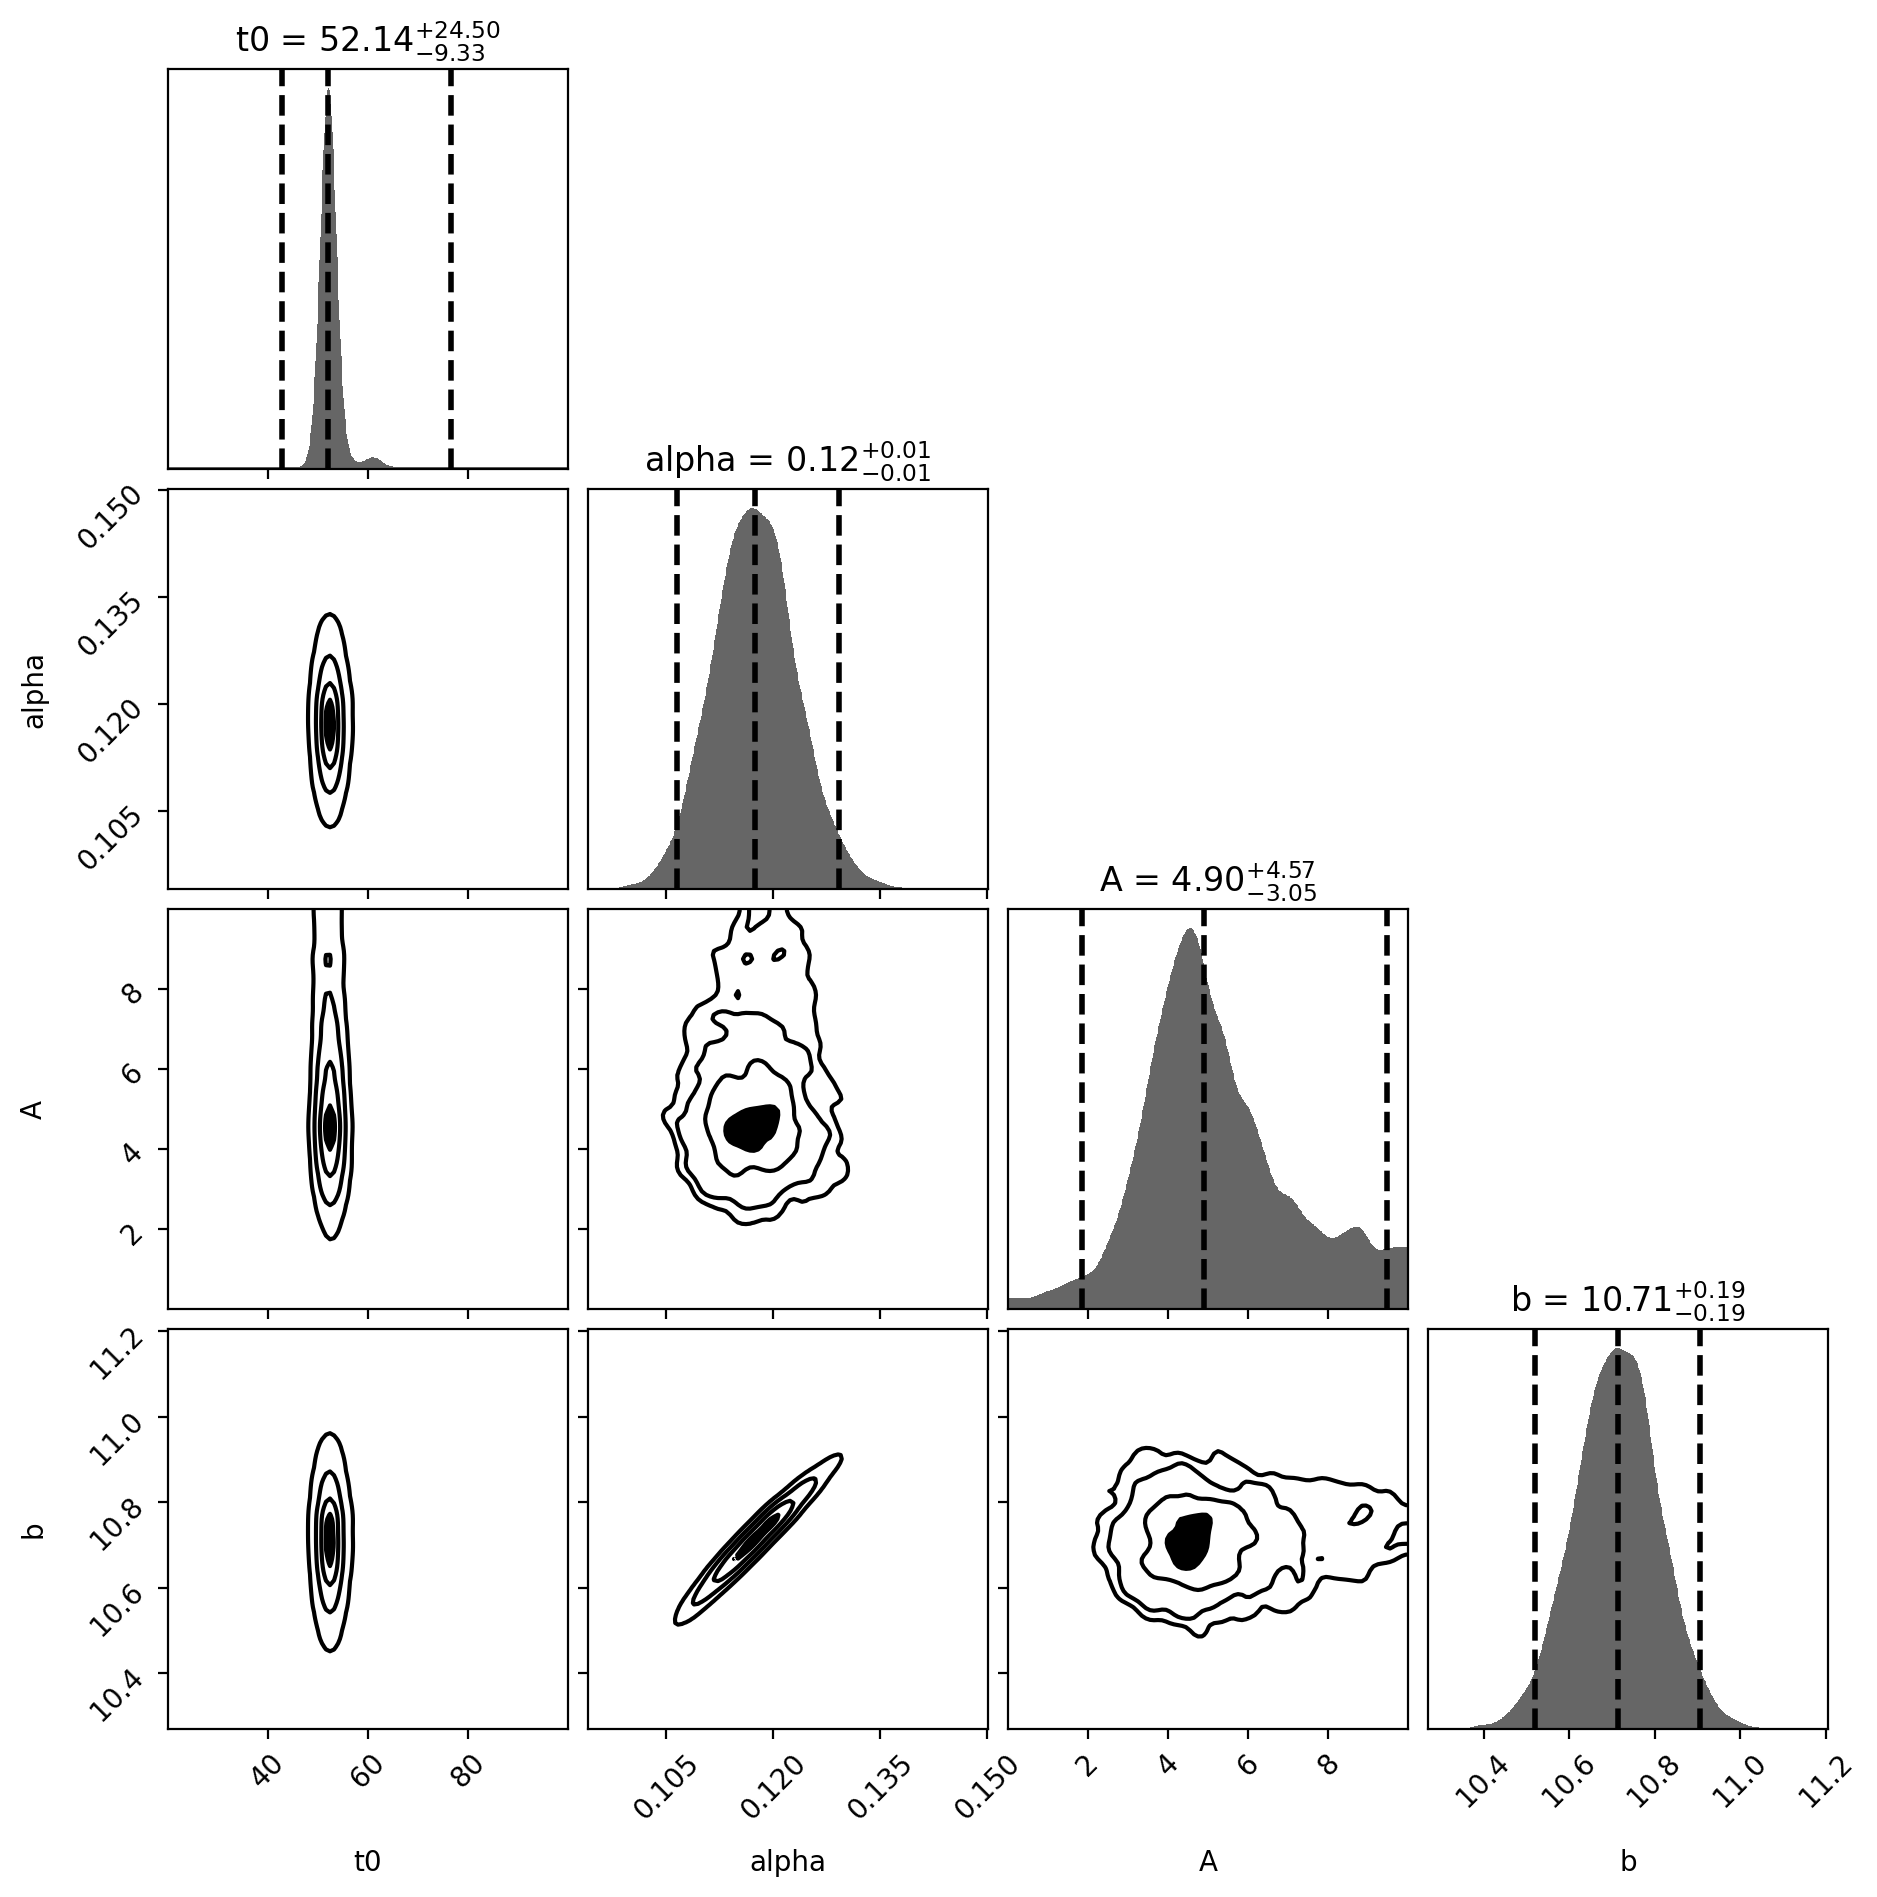

In [183]:
cfig, caxes = dyplot.cornerplot(gp_results, labels=labels, show_titles=True)

In [184]:
from dynesty import utils as dyfunc
if True:

    # Extract sampling results.
    samples = gp_results.samples  # samples
    weights = np.exp(gp_results.logwt - gp_results.logz[-1])  # normalized weights


    evidence = gp_results.logz[-1] #evidence
    print("Bayesian evidence", np.exp(evidence))

    # Compute 10%-90% quantiles.
    quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
                for samps in samples.T]
    print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

    # Compute weighted mean and covariance.
    mean, cov = dyfunc.mean_and_cov(samples, weights)
    print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))

    # Generate a new set of results with statistical+sampling uncertainties.
    # results_sim = dyfunc.simulate_run(gp_results)

Bayesian evidence 1.1417748944292326e-41
68% parameter credible regions are:
 [[52.06134736578339, 52.17875906991789], [0.11180739942411742, 0.12311509909127638], [3.5801967915015056, 7.135452720402352], [10.616152223546855, 10.808771188259309]]

Mean and covariance of parameters are: [53.09072962  0.11746063  5.21063426 10.7123519 ]
[[ 5.34288209e+01  1.88854552e-03 -2.57986589e-01  3.20162947e-02]
 [ 1.88854552e-03  3.33847736e-05 -1.34039785e-05  5.68081232e-04]
 [-2.57986589e-01 -1.34039785e-05  3.47037166e+00 -2.44304322e-04]
 [ 3.20162947e-02  5.68081232e-04 -2.44304322e-04  9.67857667e-03]]


In [185]:
np.exp(burst_results.logz[-1])/np.exp(gp_results.logz[-1])

22445701316039.906